In [1]:
import requests
import pandas as pd
from typing import Final
from blocksnet.enums import LandUse


## Пример загрузки потенциала проекта из бд

In [2]:
URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values", verify=False
)
if scenario_indicators_response.status_code != 200:
    raise Exception("Ошибка при получении индикаторов по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

LAND_USE_RULES: Final[dict[str, LandUse]] = {
    "Потенциал развития жилой застройки": LandUse.RESIDENTIAL,
    "Потенциал развития застройки общественно-деловой зоны": LandUse.BUSINESS,
    "Потенциал развития застройки рекреационной зоны": LandUse.RECREATION,
    "Потенциал развития застройки зоны специального назначения": LandUse.SPECIAL,
    "Потенциал развития застройки промышленной зоны": LandUse.INDUSTRIAL,
    "Потенциал развития застройки сельскохозяйственной зоны": LandUse.AGRICULTURE,
    "Потенциал развития застройки транспортной зоны": LandUse.TRANSPORT,
}

records: list[dict[str, object]] = []
for indicator_name, land_use in LAND_USE_RULES.items():
    potential = indicator_attributes.get(indicator_name)
    if potential is None:
        continue
    records.append({
        'land_use': land_use,
        'potential': potential,
    })

base_df = pd.DataFrame(records).reset_index(drop=True)
base_df


/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'urban-api.idu.kanootoko.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,land_use,potential
0,LandUse.BUSINESS,2.0
1,LandUse.RECREATION,4.0
2,LandUse.SPECIAL,4.0
3,LandUse.INDUSTRIAL,4.0
4,LandUse.AGRICULTURE,3.0
5,LandUse.TRANSPORT,4.0


In [3]:
# base_df.to_csv("./data/land_use_potentials.csv", index=False)

In [4]:
from urbanomy.methods.investment_potential import prepare_investment_input
scenario_blocks = pd.read_pickle('./data/blocks_with_price.pickle').to_crs(32636)
potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = scenario_blocks,
    project_potential = potential_df,
)



In [5]:
investment_input.head()


,land_use,price_pred,site_area,living_area,non_living_area,build_floor_area,share,ip_value
0,LandUse.AGRICULTURE,7.979628e+07,202399.732193,0.000000,12550.416350,12550.416350,0.918180,3.0
1,LandUse.BUSINESS,1.446378e+08,201529.493481,0.000000,40777.554163,40777.554163,0.938081,2.0
2,LandUse.TRANSPORT,7.720270e+07,164663.859830,0.000000,24985.657278,24985.657278,0.891381,4.0
3,LandUse.RESIDENTIAL,2.579618e+08,161571.832511,29356.894977,43211.816923,72568.711901,0.934862,0.0
4,LandUse.RESIDENTIAL,7.291996e+04,49.926816,0.678865,1.491128,2.169993,0.132440,0.0


## Инвевстиционная привлекательность

In [6]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 110_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 20_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 8_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}




In [7]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary


Project totals:
 • Land area:          5,759,857.12
 • Built area:         1,426,481.44
 • Land cost:          3,991,382,585.85
 • Construction cost:  54,162,070,954.00
 • Investment need:    58,153,453,539.86
 • Spatial potential:  3.13
 • Project NPV:        37,431,390,415.81
 • Project IRR:        0.22
 • Project ROI:        6.90
 • Project PP (yrs):   6.47
 • Project EI:         80.00
 • Project INV score:  79.29


,land_use,land_area,built_area,land_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.AGRICULTURE,202399.73,12550.42,7.979628e+07,3.137604e+08,3.935567e+08,8.127666e+07,0.13,4.65,13.23,26.90,3.0,46.83
1,LandUse.BUSINESS,201529.49,40777.55,1.446378e+08,2.242765e+09,2.387403e+09,1.545420e+09,0.19,9.73,9.24,73.54,2.0,63.79
2,LandUse.TRANSPORT,164663.86,24985.66,7.720270e+07,4.497418e+08,5.269445e+08,5.664706e+08,0.24,9.75,7.56,83.54,4.0,90.36
3,LandUse.RESIDENTIAL,161571.83,72568.71,2.579618e+08,3.265592e+09,3.523554e+09,2.113721e+09,0.30,4.18,4.72,98.84,0.0,57.89
4,LandUse.RESIDENTIAL,49.93,2.17,7.291996e+04,9.764970e+04,1.705697e+05,-2.000470e+03,0.10,1.60,NaN,0.00,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,LandUse.BUSINESS,606.98,203.64,4.847245e+05,1.120007e+07,1.168479e+07,9.246167e+06,0.21,11.35,8.66,30.37,2.0,38.50
63,LandUse.AGRICULTURE,2.67,NaN,1.102000e+01,NaN,1.102000e+01,4.325345e+04,0.19,9.16,9.18,22.79,3.0,44.42
64,LandUse.TRANSPORT,4307.66,688.58,2.080320e+06,1.239436e+07,1.447468e+07,1.632422e+07,0.24,10.08,7.41,39.36,4.0,64.48
65,LandUse.BUSINESS,61.63,13.49,5.678758e+04,7.418000e+05,7.985876e+05,5.877063e+05,0.20,10.20,8.87,26.27,2.0,36.10


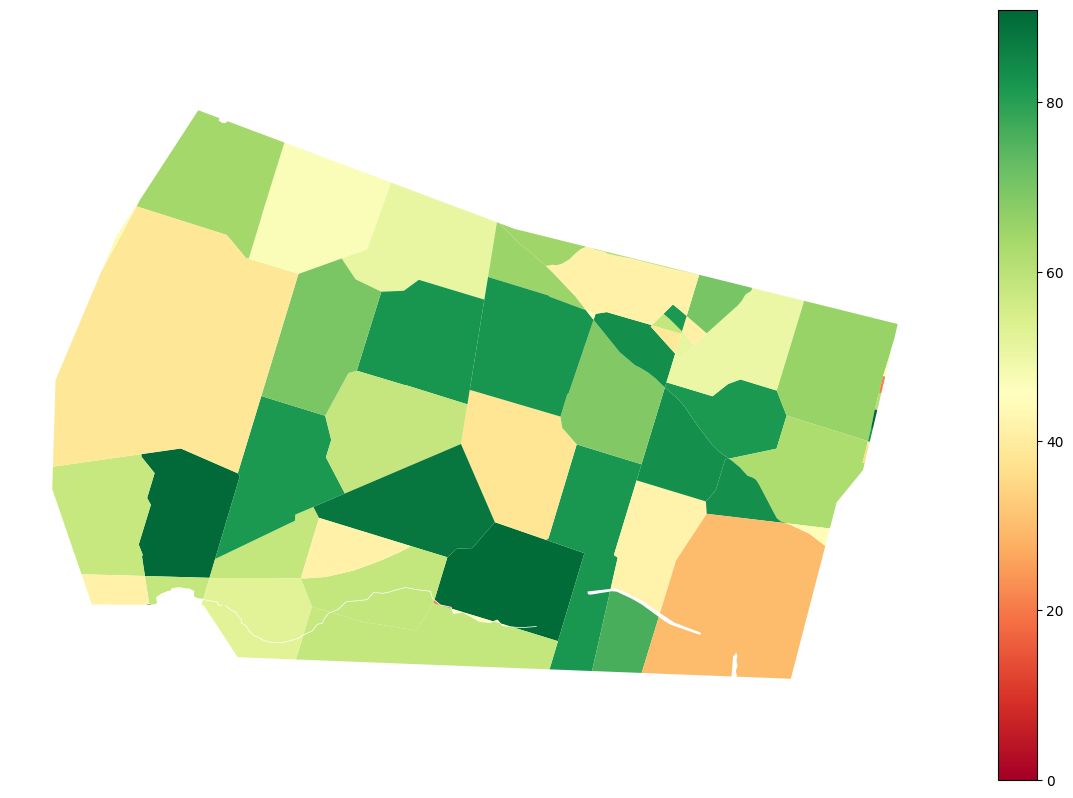

In [8]:
scn = scenario_blocks[['geometry']].join(summary)
scn.plot(column='INV', cmap='RdYlGn', legend=True, figsize=(15,10)).set_axis_off()

In [9]:
scn.to_file('./data/blocks_investment.geojson', driver='GeoJSON')